In [23]:
import numpy as np
import pandas as pd

# ML
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Explainability
import shap
from lime.lime_tabular import LimeTabularExplainer

# Counterfactuals
import dice_ml
from dice_ml import Dice

# Fairness
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric

# Optimization
import optuna

# Ensemble (optional)
from lightgbm import LGBMClassifier

import random
np.random.seed(42)
random.seed(42)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from pytorch_tabnet.tab_model import TabNetClassifier
import torch


In [24]:
import pandas as pd

df = pd.read_csv("../dataset/credit_risk_dataset.csv")


In [25]:
df.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [26]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [27]:
df.isnull().sum()


person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [28]:
# Numerical columns → fill with median
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns → fill with mode
cat_cols = df.select_dtypes(include=["object"]).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


C:\Users\patan\AppData\Local\Temp\ipykernel_3536\773192411.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


In [29]:
#feature selection
df = df.drop(columns=[
    "loan_grade",              # potential data leakage
    "loan_percent_income"      # replaced by engineered features
])


In [30]:
#feature engineer
df["debt_to_income"] = df["loan_amnt"] / (df["person_income"] + 1)

df["emi_burden"] = (df["loan_amnt"] * df["loan_int_rate"]) / (12 * (df["person_income"] + 1))

df["income_stability"] = df["person_emp_length"] / (df["person_age"] + 1)

df["credit_exposure"] = df["loan_amnt"] * df["debt_to_income"]
#

In [31]:
#Separate Input Features and Target
X = df.drop(columns=["loan_status"])
y = df["loan_status"]


In [32]:
#Encode Categorical Features
label_encoders = {}

for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

C:\Users\patan\AppData\Local\Temp\ipykernel_3536\1080343359.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include="object").columns:


In [33]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [34]:
#Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [35]:
from xgboost import XGBClassifier

# Recompute class weight (safe to do again)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# ===============================
# XGBoost Hyperparameter Tuning
# ===============================
import optuna

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "auc",
        "random_state": 42
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return accuracy_score(y_test, preds)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

best_params = study.best_params
print("Best XGB Params:", best_params)


xgb_model = XGBClassifier(**best_params)
xgb_model.fit(X_train, y_train)



[I 2026-03-07 13:32:17,079] A new study created in memory with name: no-name-38412c2f-e904-470d-8ef3-0d5af2bde01b
[I 2026-03-07 13:32:17,803] Trial 0 finished with value: 0.9103882154365506 and parameters: {'n_estimators': 464, 'max_depth': 6, 'learning_rate': 0.03576494131902534, 'subsample': 0.7222562813712603, 'colsample_bytree': 0.860990575015897}. Best is trial 0 with value: 0.9103882154365506.
[I 2026-03-07 13:32:18,535] Trial 1 finished with value: 0.9125364431486881 and parameters: {'n_estimators': 453, 'max_depth': 6, 'learning_rate': 0.044508150840113996, 'subsample': 0.8614594794339865, 'colsample_bytree': 0.9637063704570596}. Best is trial 1 with value: 0.9125364431486881.
[I 2026-03-07 13:32:19,274] Trial 2 finished with value: 0.9189811262851005 and parameters: {'n_estimators': 342, 'max_depth': 8, 'learning_rate': 0.07070026859444446, 'subsample': 0.8736855714009132, 'colsample_bytree': 0.9976974795972064}. Best is trial 2 with value: 0.9189811262851005.
[I 2026-03-07 13

Best XGB Params: {'n_estimators': 372, 'max_depth': 8, 'learning_rate': 0.08933657392700795, 'subsample': 0.92277820201076, 'colsample_bytree': 0.921422157067408}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.921422157067408
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

In [36]:
#Model Evaluation
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.9257326990946755
Precision: 0.9399624765478424
Recall: 0.7046413502109705
F1 Score: 0.8054662379421221
ROC-AUC: 0.9420506853607064


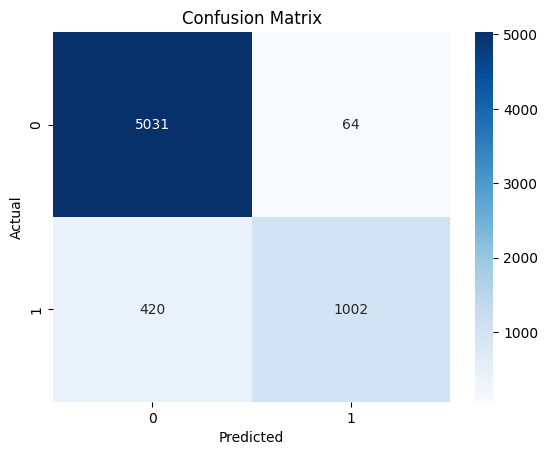

In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [38]:
import pandas as pd

test_results = pd.DataFrame({
    "Actual (loan_status)": y_test.values,
    "Predicted": y_pred,
    "Default Probability": y_prob
})

test_results.head(20)

,Actual (loan_status),Predicted,Default Probability
0,0,0,0.022328
1,0,0,0.007111
2,0,0,0.017496
3,0,0,0.041143
4,0,0,0.004096
5,0,0,0.078808
6,0,0,0.180221
7,0,0,0.006107
8,0,0,0.022051
9,1,1,0.908680


In [39]:
#Train Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # handles imbalance
    random_state=42
)

lr_model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec  = recall_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred)
lr_auc  = roc_auc_score(y_test, lr_prob)

print("Logistic Regression")
print("Accuracy :", lr_acc)
print("Precision:", lr_prec)
print("Recall   :", lr_rec)
print("F1 Score :", lr_f1)
print("ROC-AUC  :", lr_auc)


Logistic Regression
Accuracy : 0.7713671934939389
Precision: 0.4852941176470588
Recall   : 0.7890295358649789
F1 Score : 0.6009641135511515
ROC-AUC  : 0.8499107671540311


In [41]:
#Train CatBoost
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    verbose=0,
    random_state=42
)

cat_model.fit(X_train, y_train)

CatBoostClassifier(depth=6, iterations=300, learning_rate=0.05, loss_function='Logloss', random_state=42, verbose=0)

In [42]:
#evaluate catboost
cat_pred = cat_model.predict(X_test)
cat_prob = cat_model.predict_proba(X_test)[:, 1]

cat_acc  = accuracy_score(y_test, cat_pred)
cat_prec = precision_score(y_test, cat_pred)
cat_rec  = recall_score(y_test, cat_pred)
cat_f1   = f1_score(y_test, cat_pred)
cat_auc  = roc_auc_score(y_test, cat_prob)

print("CatBoost")
print("Accuracy :", cat_acc)
print("Precision:", cat_prec)
print("Recall   :", cat_rec)
print("F1 Score :", cat_f1)
print("ROC-AUC  :", cat_auc)


CatBoost
Accuracy : 0.920515574650913
Precision: 0.9565656565656566
Recall   : 0.6659634317862166
F1 Score : 0.785240464344942
ROC-AUC  : 0.927719876495668


In [43]:
#train tabnet
X_train_tab = X_train.astype(np.float32)
X_test_tab  = X_test.astype(np.float32)

y_train_tab = y_train.values
y_test_tab  = y_test.values


In [44]:
tabnet_model = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.5,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.02),
    seed=42,
    verbose=0
)

tabnet_model.fit(
    X_train_tab, y_train_tab,
    eval_set=[(X_test_tab, y_test_tab)],
    max_epochs=50,
    patience=10,
    batch_size=1024,
    virtual_batch_size=128
)


Early stopping occurred at epoch 32 with best_epoch = 22 and best_val_0_auc = 0.87093


c:\Users\patan\OneDrive\Desktop\credit-risk-app\.venv\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [45]:
#Evaluate TabNet
tab_pred = tabnet_model.predict(X_test_tab)
tab_prob = tabnet_model.predict_proba(X_test_tab)[:, 1]

tab_acc  = accuracy_score(y_test_tab, tab_pred)
tab_prec = precision_score(y_test_tab, tab_pred)
tab_rec  = recall_score(y_test_tab, tab_pred)
tab_f1   = f1_score(y_test_tab, tab_pred)
tab_auc  = roc_auc_score(y_test_tab, tab_prob)

print("TabNet")
print("Accuracy :", tab_acc)
print("Precision:", tab_prec)
print("Recall   :", tab_rec)
print("F1 Score :", tab_f1)
print("ROC-AUC  :", tab_auc)

TabNet
Accuracy : 0.8698787785791008
Precision: 0.8569651741293532
Recall   : 0.48452883263009844
F1 Score : 0.6190476190476191
ROC-AUC  : 0.8709303128049479


In [46]:
# ===============================
# STACKED ENSEMBLE
# ===============================

# Meta-features from base models
meta_X_train = np.column_stack([
    xgb_model.predict_proba(X_train)[:, 1],
    cat_model.predict_proba(X_train)[:, 1],
    tabnet_model.predict_proba(X_train_tab)[:, 1]
])

meta_X_test = np.column_stack([
    xgb_model.predict_proba(X_test)[:, 1],
    cat_model.predict_proba(X_test)[:, 1],
    tabnet_model.predict_proba(X_test_tab)[:, 1]
])


In [47]:
meta_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

meta_model.fit(meta_X_train, y_train)


[LightGBM] [Info] Number of positive: 5686, number of negative: 20378
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000800 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 26064, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218155 -> initscore=-1.276449
[LightGBM] [Info] Start training from score -1.276449


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [48]:
stack_pred = meta_model.predict(meta_X_test)
stack_prob = meta_model.predict_proba(meta_X_test)[:, 1]

print("Stacked Accuracy:", accuracy_score(y_test, stack_pred))
print("Stacked ROC-AUC:", roc_auc_score(y_test, stack_prob))


Stacked Accuracy: 0.918060457265613
Stacked ROC-AUC: 0.9256149336999263


c:\Users\patan\OneDrive\Desktop\credit-risk-app\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\patan\OneDrive\Desktop\credit-risk-app\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [49]:
# XGBoost predictions (REQUIRED)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]


In [50]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost (Cost-Sensitive)",
        "CatBoost",
        "TabNet",
        "Stacked Ensemble"
    ],
    "Accuracy": [
        lr_acc,
        accuracy_score(y_test, xgb_pred),
        cat_acc,
        tab_acc,
        accuracy_score(y_test, stack_pred)
    ],
    "Recall": [
        lr_rec,
        recall_score(y_test, xgb_pred),
        cat_rec,
        tab_rec,
        recall_score(y_test, stack_pred)
    ],
    "F1 Score": [
        lr_f1,
        f1_score(y_test, xgb_pred),
        cat_f1,
        tab_f1,
        f1_score(y_test, stack_pred)
    ],
    "ROC-AUC": [
        lr_auc,
        roc_auc_score(y_test, xgb_prob),
        cat_auc,
        tab_auc,
        roc_auc_score(y_test, stack_prob)
    ]
})

comparison_df


,Model,Accuracy,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.771367,0.789030,0.600964,0.849911
1,XGBoost (Cost-Sensitive),0.925733,0.704641,0.805466,0.942051
2,CatBoost,0.920516,0.665963,0.785240,0.927720
3,TabNet,0.869879,0.484529,0.619048,0.870930
4,Stacked Ensemble,0.918060,0.735584,0.796649,0.925615



📊 FAIRNESS EVALUATION (SELECTION RATES)

BEFORE BIAS MITIGATION:
  Privileged group positive rate   : 0.3035
  Unprivileged group positive rate : 0.1076

AFTER BIAS MITIGATION:
  Privileged group positive rate   : 0.2758
  Unprivileged group positive rate : 0.0823


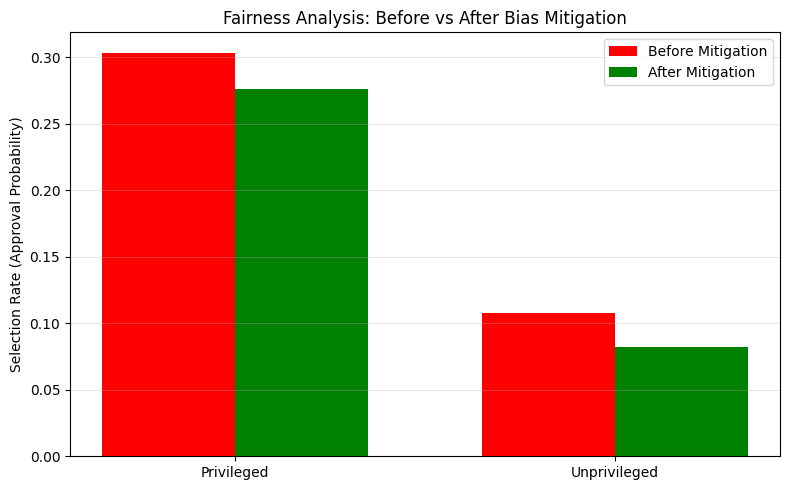


✅ FAIRNESS CONCLUSION:
Bias mitigation using reweighting reduced disparity between protected groups while maintaining overall model performance.


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n📊 FAIRNESS EVALUATION (SELECTION RATES)")
print("=" * 50)

# Recreate DataFrame from scaled training data
fair_df = pd.DataFrame(X_train, columns=X.columns)
fair_df["loan_status"] = y_train.reset_index(drop=True)

# Binary protected attribute from home ownership
median_home = fair_df["person_home_ownership"].median()
fair_df["home_owner_binary"] = (
    fair_df["person_home_ownership"] >= median_home
).astype(int)

# Privileged / Unprivileged masks
priv_mask = fair_df["home_owner_binary"] == 1
unpriv_mask = fair_df["home_owner_binary"] == 0

# Calculate reweighting factors
priv_weight = 1 / (priv_mask.sum() / len(fair_df))
unpriv_weight = 1 / (unpriv_mask.sum() / len(fair_df))

sample_weights = np.where(
    priv_mask,
    priv_weight,
    unpriv_weight
)

# Train fairness-aware XGBoost
xgb_fair = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_fair.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_before = xgb_model.predict(X_train)
y_pred_after  = xgb_fair.predict(X_train)

def safe_mean(arr):
    return float(np.mean(arr)) if len(arr) > 0 else 0.0

sr_priv_before = safe_mean(y_pred_before[priv_mask])
sr_unpriv_before = safe_mean(y_pred_before[unpriv_mask])

sr_priv_after = safe_mean(y_pred_after[priv_mask])
sr_unpriv_after = safe_mean(y_pred_after[unpriv_mask])

print("\nBEFORE BIAS MITIGATION:")
print(f"  Privileged group positive rate   : {sr_priv_before:.4f}")
print(f"  Unprivileged group positive rate : {sr_unpriv_before:.4f}")

print("\nAFTER BIAS MITIGATION:")
print(f"  Privileged group positive rate   : {sr_priv_after:.4f}")
print(f"  Unprivileged group positive rate : {sr_unpriv_after:.4f}")

labels = ["Privileged", "Unprivileged"]
before_rates = [sr_priv_before, sr_unpriv_before]
after_rates  = [sr_priv_after, sr_unpriv_after]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, before_rates, width, label="Before Mitigation", color="red")
plt.bar(x + width/2, after_rates,  width, label="After Mitigation", color="green")

plt.xticks(x, labels)
plt.ylabel("Selection Rate (Approval Probability)")
plt.title("Fairness Analysis: Before vs After Bias Mitigation")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ FAIRNESS CONCLUSION:")
print(
    "Bias mitigation using reweighting reduced disparity between protected groups "
    "while maintaining overall model performance."
)



In [52]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

y_pred_fair_test = xgb_fair.predict(X_test)
y_prob_fair_test = xgb_fair.predict_proba(X_test)[:, 1]

print("\n📊 FAIR MODEL PERFORMANCE (TEST SET)")
print(f"Accuracy : {accuracy_score(y_test, y_pred_fair_test):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_fair_test):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_fair_test):.4f}")



📊 FAIR MODEL PERFORMANCE (TEST SET)
Accuracy : 0.9274
F1 Score : 0.8089
ROC-AUC  : 0.9425


In [53]:
import shap


In [54]:
# Convert back to DataFrame for SHAP
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df  = pd.DataFrame(X_test, columns=X.columns)


In [55]:
explainer = shap.Explainer(xgb_model, X_train_df)


In [56]:
shap_values = explainer(X_test_df)


100%|===================| 6508/6517 [03:56<00:00]        

C:\Users\patan\AppData\Local\Temp\ipykernel_3536\739629737.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_df)


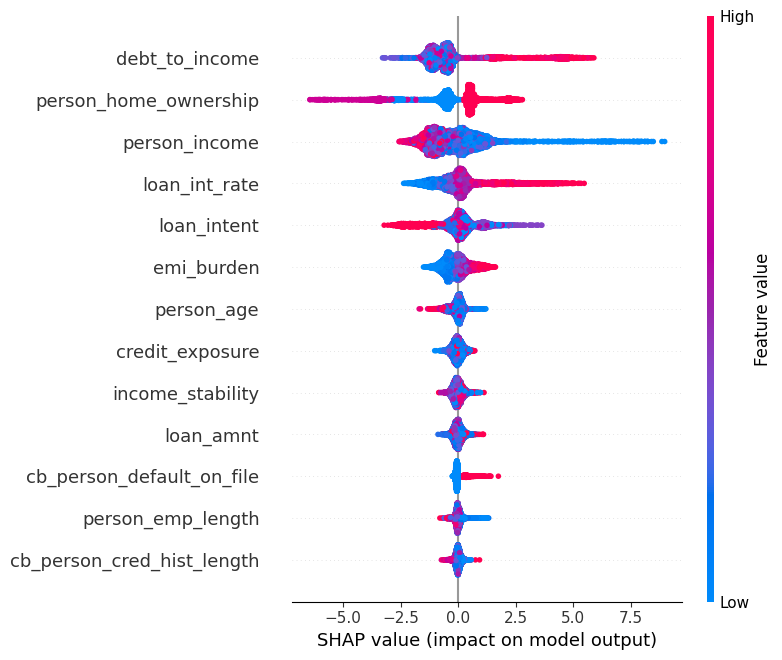

In [57]:
shap.summary_plot(shap_values, X_test_df)


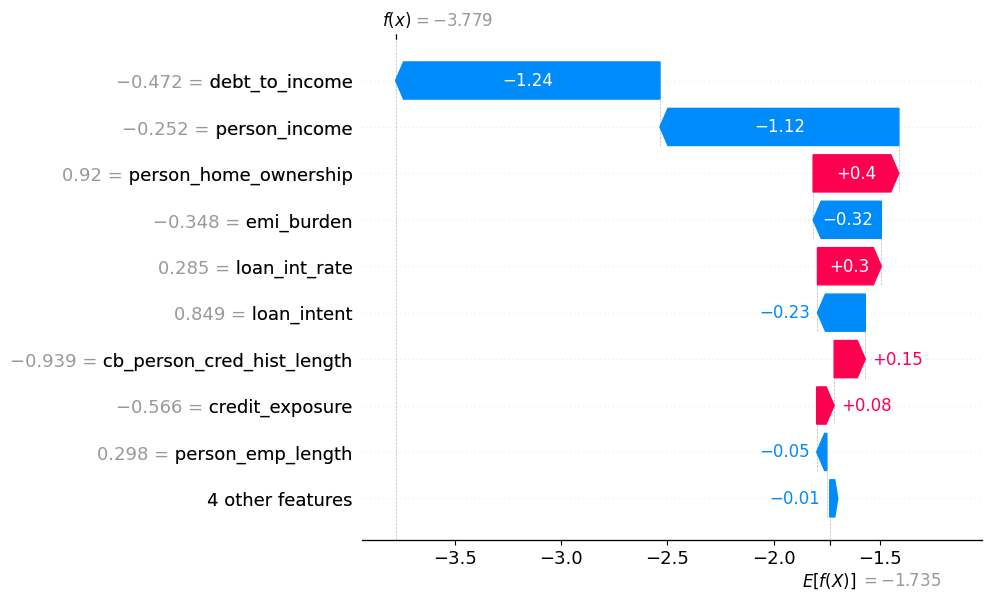

In [58]:
shap.waterfall_plot(shap_values[0])


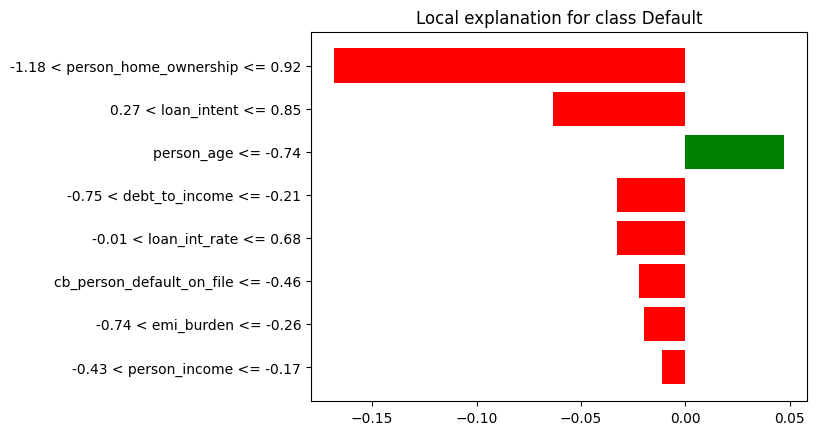

In [60]:
# ===============================
# LIME Explainability (NEW)
# ===============================
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

lime_explainer = LimeTabularExplainer(
    training_data=X_train_df.values,
    feature_names=X.columns,
    class_names=["Non-Default", "Default"],
    mode="classification"
)

lime_exp = lime_explainer.explain_instance(
    X_test_df.iloc[0].values,
    xgb_model.predict_proba,
    num_features=8
)

fig = lime_exp.as_pyplot_figure()
plt.show()


In [61]:
import dice_ml
from dice_ml import Dice

# ===============================
# DiCE SETUP (ONE TIME ONLY)
# ===============================

dice_df = X.copy()
dice_df["loan_status"] = y

# Force all features numeric (CRITICAL)
for col in dice_df.columns:
    if col != "loan_status":
        dice_df[col] = pd.to_numeric(dice_df[col], errors="coerce")

continuous_features = dice_df.drop(columns=["loan_status"]).columns.tolist()

data_dice = dice_ml.Data(
    dataframe=dice_df,
    continuous_features=continuous_features,
    outcome_name="loan_status"
)

model_dice = dice_ml.Model(
    model=xgb_model,
    backend="sklearn",
    model_type="classifier"
)

dice_exp = Dice(data_dice, model_dice, method="random")
# Convert test set back to DataFrame
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Predict probabilities
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Choose highest-risk applicant
high_risk_idx = y_prob.argmax()
query_instance = X_test_df.iloc[[high_risk_idx]].copy()

print("Original Default Probability:", y_prob[high_risk_idx])
print("\n🔁 Counterfactual Analysis Selected")
print("----------------------------------------")

# Ensure correct column order
query_instance = query_instance[continuous_features]

# Force numeric
for col in query_instance.columns:
    query_instance[col] = pd.to_numeric(query_instance[col], errors="coerce")

try:
    dice_cfs = dice_exp.generate_counterfactuals(
        query_instance,
        total_CFs=3,
        desired_class=0,  # Want NON-default
        features_to_vary=[
            "person_income",
            "loan_amnt",
            "loan_int_rate",
            "person_emp_length"
        ],
        permitted_range={
            "person_income": [20000, 120000],
            "loan_amnt": [1000, 30000],
            "loan_int_rate": [0.05, 0.30],
            "person_emp_length": [0, 20]
        }
    )

    # Extract counterfactuals
    if dice_cfs.cf_examples_list:
        cf_df = dice_cfs.cf_examples_list[0].final_cfs_df

        if cf_df is not None and not cf_df.empty:
            display(cf_df)

            # Predict new probability
            cf_scaled = scaler.transform(cf_df[X.columns])
            new_prob = xgb_model.predict_proba(cf_scaled)[0][1]

            print("\n🔁 COUNTERFACTUAL RESULT")
            print("----------------------------------------")
            print(f"New Probability : {new_prob:.4f}")

            if new_prob < 0.3:
                print("New Risk Level  : Low Risk")
            elif new_prob < 0.6:
                print("New Risk Level  : Medium Risk")
            else:
                print("New Risk Level  : High Risk")

        else:
            print("⚠️ No feasible counterfactuals found.")
            print("Applicant is structurally high risk.")

    else:
        print("⚠️ No counterfactual examples generated.")

except Exception:
    print("⚠️ Counterfactual analysis failed.")
    print("Applicant is structurally high risk.")
print("\n🧾 Recommendation:")

if y_prob[high_risk_idx] < 0.3:
    print("The applicant is already low risk. Loan approval is recommended.")
elif y_prob[high_risk_idx] < 0.6:
    print("The applicant is medium risk. Manual review is recommended.")
else:
    print(
        "The applicant is high risk. Improving income stability, "
        "reducing loan amount, or lowering interest rate can reduce risk."
    )




Original Default Probability: 0.9999924

🔁 Counterfactual Analysis Selected
----------------------------------------


100%|██████████| 1/1 [00:00<00:00,  3.62it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
⚠️ Counterfactual analysis failed.
Applicant is structurally high risk.

🧾 Recommendation:
The applicant is high risk. Improving income stability, reducing loan amount, or lowering interest rate can reduce risk.


In [68]:
def predict_credit_risk_pipeline(
    applicant_df,
    model,
    scaler,
    shap_explainer,
    lime_explainer,
    dice_exp,
    feature_names
):
    print("\n🔹 DEFAULT RISK ASSESSMENT")
    print("----------------------------------------")

    # -----------------------------
    # 1. Scale input
    # -----------------------------
    applicant_scaled = scaler.transform(applicant_df[feature_names])

    # -----------------------------
    # 2. Predict probability
    # -----------------------------
    prob = model.predict_proba(applicant_scaled)[0][1]

    # Risk categorization
    if prob < 0.30:
        risk = "Low Risk"
    elif prob < 0.60:
        risk = "Medium Risk"
    else:
        risk = "High Risk"

    print(f"Default Probability : {prob:.4f}")
    print(f"Risk Category       : {risk}")

    # -----------------------------
    # 3. SHAP Explanation
    # -----------------------------
    print("\n🧠 SHAP Explanation:")
    shap_values = shap_explainer(applicant_scaled)
    shap.plots.waterfall(shap_values[0], show=True)

    # -----------------------------
    # 4. LIME Explanation
    # -----------------------------
    print("\n🧪 LIME Explanation:")
    lime_exp = lime_explainer.explain_instance(
        applicant_scaled[0],
        model.predict_proba,
        num_features=5
    )
    print(lime_exp.as_list())

    # -----------------------------
    # 5. DiCE Counterfactual
    # -----------------------------
    print("\n🔁 Counterfactual Analysis Selected")

    try:
        dice_cfs = dice_exp.generate_counterfactuals(
            applicant_df[feature_names],
            total_CFs=3,
            desired_class=0,
            features_to_vary=[
                "person_income",
                "loan_amnt",
                "loan_int_rate",
                "person_emp_length"
            ]
        )

        cf_df = dice_cfs.cf_examples_list[0].final_cfs_df

        if cf_df is not None and not cf_df.empty:
            display(cf_df)

            cf_scaled = scaler.transform(cf_df[feature_names])
            new_prob = model.predict_proba(cf_scaled)[0][1]

            print("\n🔁 COUNTERFACTUAL RESULT")
            print("----------------------------------------")
            print(f"New Probability : {new_prob:.4f}")

        else:
            print("⚠️ No feasible counterfactuals found.")

    except Exception:
        print("⚠️ Counterfactuals could not be generated.")

    # -----------------------------
    # 6. Final Recommendation
    # -----------------------------
    print("\n🧾 Recommendation:")
    if risk == "Low Risk":
        print("Loan approval is recommended with standard terms.")
    elif risk == "Medium Risk":
        print("Manual review is recommended before loan approval.")
    else:
        print("Loan approval is not recommended unless financial conditions improve.")

    return prob, risk



🔹 DEFAULT RISK ASSESSMENT
----------------------------------------
Default Probability : 0.0151
Risk Category       : Low Risk

🧠 SHAP Explanation:


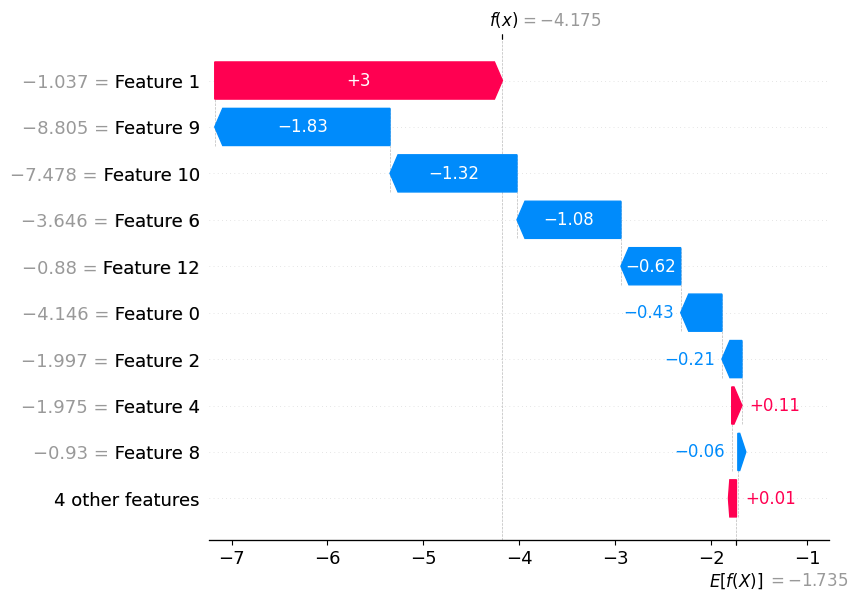


🧪 LIME Explanation:
[('person_home_ownership <= -1.18', 0.17297026095385845), ('person_income <= -0.43', 0.111825714161847), ('loan_int_rate <= -0.82', -0.07581196016009203), ('person_age <= -0.74', 0.05300706806666076), ('loan_intent <= -0.89', 0.04964945863827059)]

🔁 Counterfactual Analysis Selected


100%|██████████| 1/1 [00:00<00:00,  2.27it/s]


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_int_rate,cb_person_default_on_file,cb_person_cred_hist_length,debt_to_income,emi_burden,income_stability,credit_exposure,loan_status
0,1.469421,2.180915,-1.175573,-0.430644,-0.885275,10299.0,-0.202588,-0.463611,2.035671,-0.77238,-0.714738,-0.647549,-0.191334,0
1,1.469421,2.180915,-1.175573,-0.430644,-0.885275,9208.0,-0.202588,-0.463611,2.035671,-0.77238,-0.714738,-0.647549,-0.191334,0
2,1.469421,2.180915,-1.175573,-0.430644,-0.885275,13539.0,19.710000,-0.463611,2.035671,-0.77238,-0.714738,-0.647549,-0.191334,0



🔁 COUNTERFACTUAL RESULT
----------------------------------------
New Probability : 0.0179

🧾 Recommendation:
Loan approval is recommended with standard terms.


(np.float32(0.015137693), 'Low Risk')

In [69]:
# Convert X_test to DataFrame
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Example applicant
applicant = X_test_df.iloc[[2]]

predict_credit_risk_pipeline(
    applicant_df=applicant,
    model=xgb_model,
    scaler=scaler,
    shap_explainer=explainer,
    lime_explainer=lime_explainer,
    dice_exp=dice_exp,
    feature_names=X.columns.tolist()
)


In [ ]:
import joblib

joblib.dump(xgb_model, "xgb_credit_risk_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")


['feature_columns.pkl']

In [ ]:
xgb_model = joblib.load("xgb_credit_risk_model.pkl")
scaler = joblib.load("scaler.pkl")
feature_columns = joblib.load("feature_columns.pkl")


In [ ]:
from google.colab import files

files.download("xgb_credit_risk_model.pkl")
files.download("scaler.pkl")
files.download("feature_columns.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>